<a href="https://colab.research.google.com/github/Saumya7verma/Machine-Learning/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Import Libraries**

In [ ]:
import pandas as pd         # Used for loading and handling datasets in table format
import numpy as np          # Used for numerical operations and arrays
import matplotlib.pyplot as plt           # for plotting graphs and charts
import seaborn as sns                     # for better data visualization

from sklearn.model_selection import train_test_split          # Used to divide dataset into training data and testing data

from sklearn.preprocessing import LabelEncoder                # Used to convert categorical text values into numbers
                                                              # Example: Yes = 1, No = 0
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix           # accuracy_score -> checks model accuracy
                                                                                              # classification_report -> gives precision, recall, f1-score
                                                                                              # confusion_matrix -> shows correct and wrong predictions

from sklearn.ensemble import RandomForestClassifier           # A powerful machine learning classification algorithm
from xgboost import XGBClassifier                             # Advanced boosting algorithm for better prediction accuracy

### **Load Dataset**

In [ ]:
# Reading the CSV dataset file using pandas
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Displays the first 5 rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **Understand Dataset**

In [ ]:
# Displays detailed information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Displays statistical summary of numerical columns in the dataset

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### **Data Cleaning**

In [ ]:
'''
Removing the 'customerID' column from the dataset

'customerID' is only a unique identifier for customers
It does not help the machine learning model in prediction

axis=1 means we are removing a column
inplace=True means changes are made directly in the original dataset

'''
df.drop('customerID', axis=1, inplace=True)

In [ ]:
'''
Converting the 'TotalCharges' column from text/object type to numeric type

Some values in this column contain blank spaces or invalid text
pd.to_numeric() converts values into numbers

errors='coerce' means:
if any invalid value is found, convert it into NaN (missing value)

'''

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
'''
Removing rows that contain missing values (NaN)

NaN values were created earlier when invalid values
in 'TotalCharges' were converted using errors='coerce'

inplace=True means changes are made directly
in the original dataframe

'''
df.dropna(inplace=True)

### **Convert Categorical Data**

In [ ]:
# LabelEncoder converts text/categorical values into numbers
le = LabelEncoder()


for column in df.columns:
    # Checking if the column datatype is 'object' (text/string)
    if df[column].dtype == 'object':
        # Converting text values into numeric labels
        # Example:
        # Yes -> 1
        # No  -> 0
        df[column] = le.fit_transform(df[column])

### **Separate Features and Target**

In [ ]:
X = df.drop('Churn', axis=1)  # We are removing the target column 'Churn'
                              # X contains all independent variables/features
y = df['Churn']               # y contains only the 'Churn' column

### **Split Dataset**

In [ ]:
# Splitting the dataset into training data and testing data

X_train, X_test, y_train, y_test = train_test_split(

    # Input features
    X,

    # Target/output column
    y,

    # 20% of data will be used for testing
    # 80% will be used for training
    test_size=0.2,

    # Fixes random splitting so results remain same every time
    random_state=42
)

### **Train Random Forest Model**

In [ ]:
# Creating a Random Forest Classification model
# It uses multiple decision trees to make predictions

rf_model = RandomForestClassifier()


# Training the Random Forest model using training data

rf_model.fit(X_train, y_train)

RandomForestClassifier()

### **Predict Using Random Forest**

In [ ]:
# Making predictions using the trained Random Forest model
# to predict whether customers will churn or not

rf_pred = rf_model.predict(X_test)

### **Evaluate Random Forest**

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



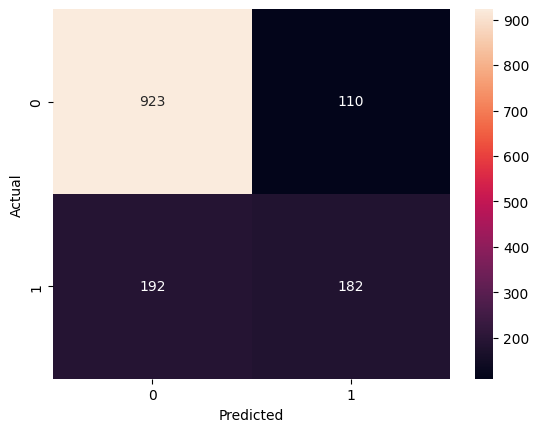

In [ ]:
# Calculating accuracy of the Random Forest model
accuracy_score(y_test, rf_pred)

# Printing detailed classification metrics - Precision, Recall, F1-score, Support
print(classification_report(y_test, rf_pred))

# Creating a confusion matrix
cm = confusion_matrix(y_test, rf_pred)

# Plotting confusion matrix using heatmap
# annot=True -> displays numbers inside boxes
# fmt='d' -> shows values as integers

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### **Train XGBoost Model**

In [ ]:
# Installing the XGBoost library in Google Colab
!pip install xgboost

# Creating an XGBoost Classification model
xgb_model = XGBClassifier()

# Training the XGBoost model using training data
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### **Predict with XGBoost**

In [ ]:
xgb_pred = xgb_model.predict(X_test)

### **Evaluate XGBoost**

In [ ]:
# Calculating accuracy of the XGBoost model
accuracy_score(y_test, xgb_pred)

# Printing detailed classification metrics - Precision, Recall, F1-score, Support
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1033
           1       0.57      0.49      0.52       374

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.68      1407
weighted avg       0.75      0.76      0.76      1407



### **Feature Importance**

In [ ]:
# Getting feature importance values from the trained Random Forest model
importance = rf_model.feature_importances_

# Creating a DataFrame to display:
# Feature names and their importance scores together

feature_importance = pd.DataFrame({

    # Column names/features from dataset
    'Feature': X.columns,

    # Importance score of each feature
    'Importance': importance
})



# Sorting features by importance in descending order

feature_importance = feature_importance.sort_values(

    # Sort based on Importance column
    by='Importance',

    # descending order
    ascending=False
)

print(feature_importance)

             Feature  Importance
18      TotalCharges    0.183363
17    MonthlyCharges    0.178593
4             tenure    0.155340
14          Contract    0.089814
16     PaymentMethod    0.050769
11       TechSupport    0.045558
8     OnlineSecurity    0.044245
0             gender    0.028148
7    InternetService    0.027561
15  PaperlessBilling    0.024736
9       OnlineBackup    0.024677
2            Partner    0.022951
6      MultipleLines    0.022507
1      SeniorCitizen    0.021554
10  DeviceProtection    0.021532
3         Dependents    0.019315
12       StreamingTV    0.017349
13   StreamingMovies    0.016878
5       PhoneService    0.005111


### **Visualize Feature Importance**

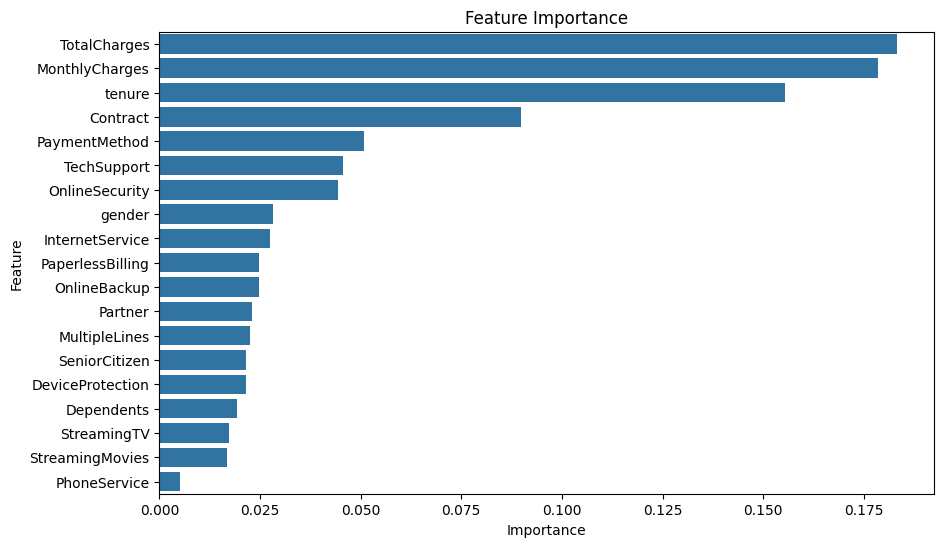

In [ ]:
# Creating a figure/canvas for the graph
# figsize=(10,6) sets:
# width = 10
# height = 6

plt.figure(figsize=(10,6))

# Creating a bar plot using seaborn

sns.barplot(

    # Importance values on x-axis
    x='Importance',

    # Feature names on y-axis
    y='Feature',

    # Dataset containing feature importance information
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

### **Compare Models**

In [ ]:
# Importing evaluation metrics from sklearn
# recall_score    -> how many actual churns were detected
# f1_score        -> balance between precision and recall

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
# Random Forest Model Metrics

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

In [ ]:
# XGBoost Model Metrics

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test, xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

In [ ]:
# Creating Model Comparison Table
# Creating a DataFrame to compare both models

comparison = pd.DataFrame({

    'Model': ['Random Forest', 'XGBoost'],

    'Accuracy': [rf_accuracy, xgb_accuracy],

    'Precision': [rf_precision, xgb_precision],

    'Recall': [rf_recall, xgb_recall],

    'F1-Score': [rf_f1, xgb_f1]
})

# Displaying the comparison table
print(comparison)

           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.785359   0.623288  0.486631  0.546547
1        XGBoost  0.764037   0.565217  0.486631  0.522989


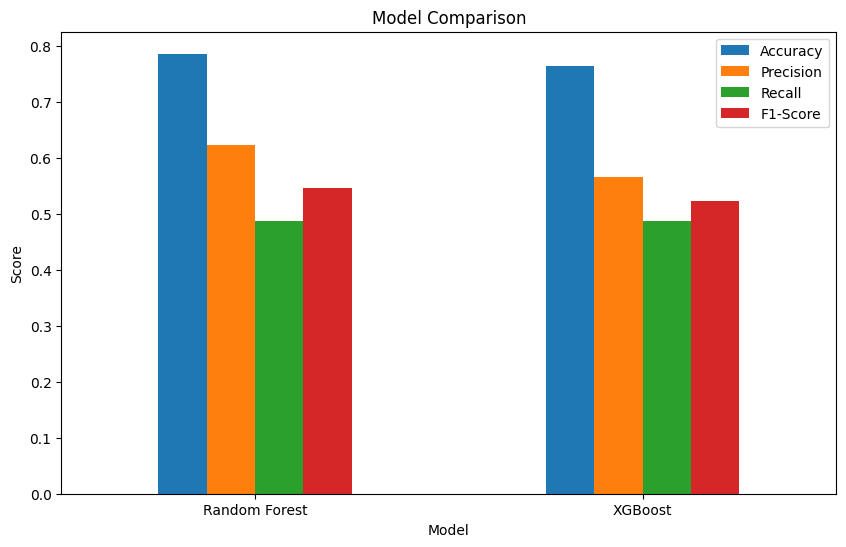

In [ ]:
comparison.set_index('Model').plot(kind='bar', figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### **Final Result**

In [ ]:
print(X.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')


In [ ]:
# Taking dynamic input from user

gender = int(input("Enter Gender (0 = Female, 1 = Male): "))
senior = int(input("Senior Citizen? (0 = No, 1 = Yes): "))
partner = int(input("Partner? (0 = No, 1 = Yes): "))
dependents = int(input("Dependents? (0 = No, 1 = Yes): "))
tenure = int(input("Tenure (months): "))
phone = int(input("Phone Service? (0 = No, 1 = Yes): "))
multiple = int(input("Multiple Lines (0 = No, 1 = Yes): "))
internet = int(input("Internet Service (0/1/2): "))
security = int(input("Online Security (0 = No, 1 = Yes): "))
backup = int(input("Online Backup (0 = No, 1 = Yes): "))
protection = int(input("Device Protection (0 = No, 1 = Yes): "))
support = int(input("Tech Support (0 = No, 1 = Yes): "))
tv = int(input("Streaming TV (0 = No, 1 = Yes): "))
movies = int(input("Streaming Movies (0 = No, 1 = Yes): "))
contract = int(input("Contract Type (0/1/2): "))
paperless = int(input("Paperless Billing (0 = No, 1 = Yes): "))
payment = int(input("Payment Method (0/1/2/3): "))
monthly = float(input("Monthly Charges: "))
total = float(input("Total Charges: "))

Enter Gender (0 = Female, 1 = Male): 1
Senior Citizen? (0 = No, 1 = Yes): 0
Partner? (0 = No, 1 = Yes): 0
Dependents? (0 = No, 1 = Yes): 1
Tenure (months): 3
Phone Service? (0 = No, 1 = Yes): 1
Multiple Lines (0 = No, 1 = Yes): 1
Internet Service (0/1/2): 1
Online Security (0 = No, 1 = Yes): 0
Online Backup (0 = No, 1 = Yes): 0
Device Protection (0 = No, 1 = Yes): 0
Tech Support (0 = No, 1 = Yes): 1
Streaming TV (0 = No, 1 = Yes): 1
Streaming Movies (0 = No, 1 = Yes): 1
Contract Type (0/1/2): 1
Paperless Billing (0 = No, 1 = Yes): 1
Payment Method (0/1/2/3): 2
Monthly Charges: 2345
Total Charges: 1234455


In [ ]:
# Create customer data
new_customer = [[
    gender,
    senior,
    partner,
    dependents,
    tenure,
    phone,
    multiple,
    internet,
    security,
    backup,
    protection,
    support,
    tv,
    movies,
    contract,
    paperless,
    payment,
    monthly,
    total
]]


In [ ]:
prediction = xgb_model.predict(new_customer)

print(prediction)

[1]


In [ ]:
if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is likely to stay")

Customer is likely to churn
